In [1]:
pip install requests beautifulsoup4 lxml

Note: you may need to restart the kernel to use updated packages.


### Building a function to parse recipes from websites

In [2]:
import requests 
from bs4 import BeautifulSoup
import json

# Extract ingredient list from a recipe page using schema.org JSON-LD
def extract_ingredients(url):
    headers = {
    "User-Agent": "Chrome/91.0.4472.120"
    }
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "lxml")
    scripts = soup.find_all("script", type="application/ld+json")
    for script in scripts:
        if not script.string:
            continue
        if "recipeIngredient" not in script.string:
            continue
        try: 
            data = json.loads(script.string.strip())
        except json.JSONDecodeError:
            continue

        # handle simple Recipe JSON directly
        if isinstance(data, dict) and data.get("@type") == "Recipe": 
            ingredients = data.get("recipeIngredient", [])
            return {"Recipe_url": url, "Ingredients": ingredients}

        if isinstance(data, dict):
            candidates = data.get("@graph", [data])

        elif isinstance(data, list):
            candidates = data 
        
        else: 
            continue

        for item in candidates:
            if not isinstance(item, dict):
                continue
            
            ingredients = item.get("recipeIngredient", [])
            
            if ingredients:
                return {"Recipe_url": url, "Ingredients": ingredients}
         
    return None 


In [3]:
test = extract_ingredients("https://ashbaber.com/easy-fudgy-blondies/")
print(test)

{'Recipe_url': 'https://ashbaber.com/easy-fudgy-blondies/', 'Ingredients': ['160g unsalted butter', '200g brown sugar', '100g granulated sugar', '2 teaspoons vanilla extract', '2 eggs', '240g plain flour', '1/2 teaspoon salt', '1/4 teaspoon baking powder', '150g chocolate, chopped (I used a mixture of white and dark chocolate)']}


### Making a dataframe (df) out of the parsed data

In [4]:
import pandas as pd

df_urls = pd.read_csv("blondie_urls.csv")

df_urls.describe()

df_urls = df_urls.drop_duplicates(subset=["URLs"])
df_urls = df_urls.dropna(subset=["URLs"])

In [5]:
urls = df_urls["URLs"].tolist()
print(len(urls))

35


In [6]:
dataset = []
for url in urls:
    recipe = extract_ingredients(url)
    if recipe:
        dataset.append(recipe)
    else:
        print(f"Failed to extract from: {url}")

Failed to extract from: https://www.inspiredtaste.net/23801/no-fail-blondies-recipe/ 
Failed to extract from: https://smittenkitchen.com/2006/11/blondies/
Failed to extract from: https://www.thepancakeprincess.com/best-blondie-bake-off/
Failed to extract from: https://fussfreeflavours.com/best-blondie-recipes/


In [7]:
print(len(dataset))

31


In [8]:
df = pd.DataFrame(dataset)

df.describe()

,Recipe_url,Ingredients
count,31,31
unique,31,31
top,https://sugarspunrun.com/blondies-recipe/,"[1 cup unsalted butter (melted), 1 ¼ cup brown..."
freq,1,1


In [9]:
df["Ingredients"].sample(20)

5     [160g unsalted butter, 200g brown sugar, 100g ...
8     [1/2 cup (1 stick) unsalted butter, melted, 1 ...
17    [½ cup butter (softened), 2 cups brown sugar, ...
28    [3/4 c. unsalted butter, Nonstick cooking spra...
1     [1¾ cups all-purpose flour ((210g)), 1 teaspoo...
13    [12 tbsp (1 ½ sticks) unsalted butter, 2 large...
14    [1/2 cup unsalted butter, melted, 1 cup packed...
23    [½  cup unsalted butter, melted ((1 stick)), 1...
7     [2 cups all-purpose flour, 1 teaspoon baking p...
22    [175g  butter cut into cubes, plus extra for t...
25    [150g unsalted butter, cold from the fridge is...
26    [1 cup Unsalted butter (almost melted), ½ cup ...
4     [¾ cup unsalted butter (1½ sticks, sliced into...
19    [1 ¼ cup brown sugar, 2 large eggs, 2 teaspoon...
20    [1 cup (8 oz/225 g) butter,  (melted and coole...
30    [1 1/2  cups    butter, softened , 1 2/3  cups...
2     [125g/8 tbsp (1 US stick)  unsalted butter ((N...
11    [1 1/2 sticks (170 grams) unsalted butter,

### Altering the df to show each ingredient instead of the recipe as a whole

In [10]:
df = df.explode("Ingredients").reset_index(drop=True)

In [11]:
print(len(df))

271


### Making a "grams" column in df to show the weight of ingredients in grams

In [12]:
def get_grams(text):
    import re
    match = re.search(r"(\d+\.?\d*)\s*g", text.lower())
    if match:
        return float(match.group(1))
    return None

In [13]:
df["grams"] = df["Ingredients"].apply(get_grams)

In [14]:
df.sample(10)

,Recipe_url,Ingredients,grams
231,https://veenaazmanov.com/classic-blondies-recipe/,½ tsp Baking soda,NaN
171,https://www.tastingtable.com/2122453/best-butt...,2 teaspoons vanilla extract,NaN
20,https://www.recipetineats.com/blondies/,125g/8 tbsp (1 US stick) unsalted butter ((No...,125.0
186,https://moleinthewall.com/classic-blondie-recipe/,2 eggs(or vegan egg replacement),NaN
70,https://www.smalltownwoman.com/blondies-recipe/,1 cup unsalted butter melted and slightly cooled,NaN
223,https://cloudykitchen.com/blog/brown-butter-bl...,"220g white chocolate, roughly chopped, plus mo...",220.0
133,https://bromabakery.com/the-best-chewy-blondies/,1/2 teaspoon salt,NaN
80,https://eatsdelightful.com/classic-blondie-bar...,1 teaspoon pure vanilla extract,NaN
121,https://www.wyseguide.com/classic-blondies/,2 cups light brown sugar,NaN
6,https://sugarspunrun.com/blondies-recipe/,2 teaspoons cornstarch,NaN


### Normalising fractions in list of ingredients

In [15]:
df[df["Ingredients"].str.contains("⅕|⅖|⅗|⅘",na=False)]

,Recipe_url,Ingredients,grams


In [16]:
df[df["Ingredients"].str.contains("11/2",na=False)]

,Recipe_url,Ingredients,grams


In [17]:
def normalise_fractions(text):
    import re
    
    # Step 1: add space between number and unicode fraction
    text = re.sub(r"(\d)([½¼¾⅓⅔])", r"\1 \2", text)

    replacements = {
        "½": "1/2",
        "¼": "1/4",
        "¾": "3/4",
        "⅓": "1/3",
        "⅔": "2/3"}
    for k, v in replacements.items():
        text = text.replace(k, v)
    return text

In [18]:
df["Ingredients"] = df["Ingredients"].apply(normalise_fractions)

In [19]:
df[df["Ingredients"].str.contains("½|¼|¾|⅓|⅔",na=False)]

,Recipe_url,Ingredients,grams


### Ensuring compact fractions are fixed (eg: 13/4 is computed as 1 and 3/4 instead of 13/4)

In [20]:
def fix_compact_fractions(text):
    import re
    text = re.sub(r"\b(\d)(\d)/(\d)\b", r"\1 \2/\3", text)
    return text

In [21]:
df["Ingredients"] = df["Ingredients"].apply(fix_compact_fractions)

In [22]:
df[df["Ingredients"].str.contains("13/4",na=False)]

,Recipe_url,Ingredients,grams


In [23]:
df[df["Ingredients"].str.contains("11/2",na=False)]

,Recipe_url,Ingredients,grams


### Extracts the first numeric amount from a text string; handles **mixed numbers**(1 1/2), **fractions** (3/4) and **integers/decimals**(2 or 2.5)

In [24]:
def get_amount(text):
    import re
    match = re.search(r"(\d+\s\d+/\d+|\d+/\d+|\d+\.?\d*)", text)
    if match:
        return match.group(1)
    return None

df["amount_raw"] = df["Ingredients"].apply(get_amount)

### Converting the numeric amount into float

In [25]:
def amount_to_float(text):
    if text is None:
        return None
    # case 1: Mixed number (e.g., "1 1/2")
    if " " in text:
        whole, frac = text.split(" ")
        num, den = frac.split("/")
        return float(whole) + float(num) / float(den)
    # case 2: Simple fraction (e.g., "1/2")
    if "/" in text:
        num, den = text.split("/")
        return float(num) / float(den)
    # case 3: Simple number (e.g., "1", "1.5")
    return float(text)

In [26]:
df["amount_float"] = df["amount_raw"].apply(amount_to_float)

In [27]:
df.sample(10)

,Recipe_url,Ingredients,grams,amount_raw,amount_float
195,https://www.bbcgoodfood.com/recipes/easy-blondies,1 tsp vanilla extract or bean paste,NaN,1,1.0
198,https://www.bbcgoodfood.com/recipes/easy-blondies,"200g white chocolate chopped, or use white ch...",200.0,200,200.0
44,https://www.loveandlemons.com/blondie-recipe/,1 1/2 cups all-purpose flour (spooned and leve...,NaN,1 1/2,1.5
185,https://moleinthewall.com/classic-blondie-recipe/,1.5 cup brown sugar,NaN,1.5,1.5
94,https://www.livewellbakeoften.com/blondie-recipe/,2 large eggs (at room temperature),NaN,2,2.0
141,https://www.somethingswanky.com/classic-chocol...,pinch of salt,NaN,None,NaN
69,https://www.smalltownwoman.com/blondies-recipe/,1/2 teaspoon salt,NaN,1/2,0.5
246,https://www.thepioneerwoman.com/food-cooking/r...,1 tsp. baking powder,NaN,1,1.0
225,https://veenaazmanov.com/classic-blondies-recipe/,1/2 cup White sugar,NaN,1/2,0.5
70,https://www.smalltownwoman.com/blondies-recipe/,1 cup unsalted butter melted and slightly cooled,NaN,1,1.0


In [28]:
df[df["Ingredients"].str.contains("gram", na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float
56,https://joythebaker.com/2023/02/my-best-classi...,1 cup (about 100 grams) walnut halves and pieces,100.0,1,1.00
57,https://joythebaker.com/2023/02/my-best-classi...,1 1/2 cups (190 grams) all-purpose flour,190.0,1 1/2,1.50
60,https://joythebaker.com/2023/02/my-best-classi...,"1 1/2 sticks (12 tablespoons, 179 grams) unsal...",179.0,1 1/2,1.50
61,https://joythebaker.com/2023/02/my-best-classi...,1 1/4 cup (250 grams) lightly packed light or ...,250.0,1 1/4,1.25
91,https://www.livewellbakeoften.com/blondie-recipe/,Â3/4 cup unsalted butter (melted and slightly ...,170.0,3/4,0.75
92,https://www.livewellbakeoften.com/blondie-recipe/,1 cup packed light brown sugar ((200 grams) ),200.0,1,1.00
93,https://www.livewellbakeoften.com/blondie-recipe/,Â3/4 cup granulated sugar ((150 grams) ),150.0,3/4,0.75
99,https://www.livewellbakeoften.com/blondie-recipe/,1 cup white chocolate chips (optional (190 gra...,190.0,1,1.00
100,https://handletheheat.com/blondie-recipe/,1 1/2 sticks (170 grams) unsalted butter,170.0,1 1/2,1.50
101,https://handletheheat.com/blondie-recipe/,1 1/2 cups (300 grams) light brown sugar,300.0,1 1/2,1.50


In [29]:
df[df["Recipe_url"].str.contains("ashbaber", na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float
47,https://ashbaber.com/easy-fudgy-blondies/,160g unsalted butter,160.0,160,160.00
48,https://ashbaber.com/easy-fudgy-blondies/,200g brown sugar,200.0,200,200.00
49,https://ashbaber.com/easy-fudgy-blondies/,100g granulated sugar,100.0,100,100.00
50,https://ashbaber.com/easy-fudgy-blondies/,2 teaspoons vanilla extract,NaN,2,2.00
51,https://ashbaber.com/easy-fudgy-blondies/,2 eggs,NaN,2,2.00
52,https://ashbaber.com/easy-fudgy-blondies/,240g plain flour,240.0,240,240.00
53,https://ashbaber.com/easy-fudgy-blondies/,1/2 teaspoon salt,NaN,1/2,0.50
54,https://ashbaber.com/easy-fudgy-blondies/,1/4 teaspoon baking powder,NaN,1/4,0.25
55,https://ashbaber.com/easy-fudgy-blondies/,"150g chocolate, chopped (I used a mixture of w...",150.0,150,150.00


### Extracting unit of measurement of each ingredient

In [30]:
def get_unit(text):
    import re
    match = re.search(r"\b(cups|cup|c\.|tablespoons|tablespoon|teaspoons|teaspoon|tbsp|tsps|tsp|grams|gram|g|sticks|stick|ounces|ounce|oz)", text.lower())
    if match:
        unit = match.group(1)
        if unit == "c.":
            return "cup"
        return unit
    return None

df["unit"] = df["Ingredients"].apply(get_unit)

In [31]:
df.sample(20)

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit
240,https://icecreaminspiration.com/classic-blondi...,2 teaspoons baking powder,NaN,2,2.00,teaspoons
113,https://cakesbymk.com/recipe/easy-blondies-rec...,3/4 cup white chocolate (cut into small chunks...,NaN,3/4,0.75,cup
92,https://www.livewellbakeoften.com/blondie-recipe/,1 cup packed light brown sugar ((200 grams) ),200.0,1,1.00,cup
70,https://www.smalltownwoman.com/blondies-recipe/,1 cup unsalted butter melted and slightly cooled,NaN,1,1.00,cup
153,https://www.giftofhospitality.com/really-good-...,1/2 cup butter (softened),NaN,1/2,0.50,cup
203,https://www.rachelcooks.com/blondie-recipe/,1 cup all-purpose flour,NaN,1,1.00,cup
160,https://www.giftofhospitality.com/really-good-...,1 cup chopped pecans,NaN,1,1.00,cup
239,https://icecreaminspiration.com/classic-blondi...,1 1/2 cups all-purpose flour,NaN,1 1/2,1.50,cups
8,https://sugarspunrun.com/blondies-recipe/,1 teaspoon salt,NaN,1,1.00,teaspoon
235,https://icecreaminspiration.com/classic-blondi...,1/2 cup vegetable oil,NaN,1/2,0.50,cup


In [32]:
df[df["Ingredients"].str.contains("egg", case=False, na=False)][["Ingredients", "unit"]]

,Ingredients,unit
3,2 large eggs + 1 egg yolk (room temperature p...,None
17,1 large egg (room temperature),None
22,1 large egg ((~50g/2 oz)),oz
31,"1 large egg, lightly beaten",None
40,2 large eggs,None
41,1 large egg yolk,None
51,2 eggs,None
63,2 large eggs,None
73,2 large eggs room temperature (lightly beaten),None
79,"1 large egg, at room temperature",None


In [33]:
df[df["Ingredients"].str.contains("cornstarch", case=False, na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit
6,https://sugarspunrun.com/blondies-recipe/,2 teaspoons cornstarch,NaN,2,2.00,teaspoons
110,https://cakesbymk.com/recipe/easy-blondies-rec...,1/4 cup cornstarch,NaN,1/4,0.25,cup
258,https://iambaker.net/blondie-recipe/,2 teaspoons cornstarch,NaN,2,2.00,teaspoons


### Assigning an "Ingredient type" for ingredients; butter, flour, sugar, egg vanilla etc

In [34]:
def get_ingredient_type(text):
    import re

    text = text.lower()
    keywords = ["butter", "flour", "sugar", "egg", "vanilla"]

    for word in keywords:
        if re.search(rf"\b{word}\b", text):
            return word
    if re.search(r"baking powder|baking soda", text):
        return "baking_powder"
    elif re.search(r"cornstarch", text):
        return "cornstarch"
    elif re.search(r"salt", text):
        return "salt"
    else:
        return "add_ins"

In [35]:
df["ingredient_type"] = df["Ingredients"].apply(get_ingredient_type)

In [36]:
df[df["ingredient_type"] == "add_ins"]

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type
9,https://sugarspunrun.com/blondies-recipe/,2/3 cup white chocolate chips ((see note)),NaN,2/3,0.666667,cup,add_ins
10,https://sugarspunrun.com/blondies-recipe/,"1 cup chopped walnuts ((may omit, see note))",NaN,1,1.000000,cup,add_ins
19,https://preppykitchen.com/blondie-recipe/,"1 cup mix-in’s (such as white, semi-sweet choc...",180.0,1,1.000000,cup,add_ins
26,https://www.recipetineats.com/blondies/,1 cup white chocolate chips,NaN,1,1.000000,cup,add_ins
27,https://www.recipetineats.com/blondies/,"1/2 cup walnuts (, roughly chopped)",NaN,1/2,0.500000,cup,add_ins
37,https://www.simplyrecipes.com/recipes/blondies/,1/3 cup (60 g) butterscotch chips (chopped wal...,60.0,1/3,0.333333,cup,add_ins
40,https://www.loveandlemons.com/blondie-recipe/,2 large eggs,NaN,2,2.000000,None,add_ins
45,https://www.loveandlemons.com/blondie-recipe/,1/2 cup chopped walnuts (plus more for topping),NaN,1/2,0.500000,cup,add_ins
46,https://www.loveandlemons.com/blondie-recipe/,1/2 cup white chocolate chips (plus more for t...,NaN,1/2,0.500000,cup,add_ins
51,https://ashbaber.com/easy-fudgy-blondies/,2 eggs,NaN,2,2.000000,None,add_ins


In [37]:
df.sample(20)

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type
194,https://www.bbcgoodfood.com/recipes/easy-blondies,3 eggs,NaN,3,3.000000,None,add_ins
159,https://www.giftofhospitality.com/really-good-...,1/2 teaspoon salt,NaN,1/2,0.500000,teaspoon,salt
86,https://www.fivehearthome.com/easy-one-bowl-bl...,1 egg (at room temperature),NaN,1,1.000000,None,egg
230,https://veenaazmanov.com/classic-blondies-recipe/,1 tsp Baking powder,NaN,1,1.000000,tsp,baking_powder
25,https://www.recipetineats.com/blondies/,1/4 tsp cooking salt / kosher salt ((halve for...,NaN,1/4,0.250000,tsp,salt
78,https://eatsdelightful.com/classic-blondie-bar...,"1 cup light or dark brown sugar, packed * see ...",NaN,1,1.000000,cup,sugar
247,https://www.thepioneerwoman.com/food-cooking/r...,1 tsp. salt,NaN,1,1.000000,tsp,salt
210,https://www.cookwithkushi.com/best-blondie-rec...,1 cup Brown sugar (200g),200.0,1,1.000000,cup,sugar
246,https://www.thepioneerwoman.com/food-cooking/r...,1 tsp. baking powder,NaN,1,1.000000,tsp,baking_powder
87,https://www.fivehearthome.com/easy-one-bowl-bl...,1 teaspoon pure vanilla extract,NaN,1,1.000000,teaspoon,vanilla


In [38]:
df[df["ingredient_type"].str.contains("flour", case=False, na=False)][["ingredient_type", "grams", "unit"]]

,ingredient_type,grams,unit
5,flour,NaN,cups
11,flour,210.0,cups
24,flour,NaN,cup
33,flour,128.0,cup
44,flour,NaN,cups
52,flour,240.0,None
57,flour,190.0,cups
67,flour,NaN,cups
81,flour,NaN,cup
88,flour,NaN,cup


### Converting all units of measurment into grams for ease of computing

In [39]:
def convert_to_grams(row):

    if pd.notna(row["grams"]):
        return row["grams"]
    
    ingredient = row["ingredient_type"]
    amount = row["amount_float"]
    unit = row["unit"]

    cup = ["cup", "cups"]
    tbsp = ["tablespoons", "tablespoon", "tbsp"]
    tsp = ["teaspoons", "teaspoon", "tsps", "tsp"]
    oz = ["oz", "ounce", "ounces"]

    if amount is None:
        return None
    
    # Butter
    if ingredient == "butter":
        if unit in cup:
            return amount * 227
        elif unit in tbsp:
            return amount * 14
        elif unit in tsp:
            return amount * 5
        elif unit in oz:
            return amount * 28.35
        elif unit in ["sticks", "stick"]:
            return amount * 113

    # Flour
    elif ingredient == "flour":
        if unit in cup:
            return amount * 120
        elif unit in tbsp:
            return amount * 8
        elif unit in tsp:
            return amount * 3
        elif unit in oz:
            return amount * 28.35
        
    # Sugar
    elif ingredient == "sugar":
         if unit in cup:
            return amount * 200
         elif unit in tbsp:
            return amount * 12.5
         elif unit in tsp:
            return amount * 4
         elif unit in oz:
            return amount * 28.35
         
    # Vanilla
    elif ingredient == "vanilla":
        if unit in tsp:
            return amount * 5   # 1 tsp ≈ 5g/ml
        elif unit in tbsp:
            return amount * 15  # 1 tbsp = 3 tsp
        
    # Baking Powder
    elif ingredient == "baking_powder":
        if unit in tsp:
            return amount * 4   # 1 tsp ≈ 4g
        elif unit in tbsp:
            return amount * 12  # 1 tbsp = 3 tsp

    # Cornstarch
    elif ingredient == "cornstarch":
        if unit in tsp:
            return amount * 3   # 1 tsp ≈ 3g
        elif unit in tbsp:
            return amount * 9   # 1 tbsp = 3 tsp
        elif unit in cup:
            return amount * 120 # 1 cup ≈ 120g         
    return None

In [40]:
df.head(10).apply(convert_to_grams, axis=1)

0    227.0
1    250.0
2    100.0
3      NaN
4     10.0
5    270.0
6      6.0
7      2.0
8      NaN
9      NaN
dtype: float64

In [41]:
df["grams_converted"] = df.apply(convert_to_grams, axis=1)

In [42]:
df[df["Ingredients"].str.contains("baking powder", na=False)]

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type,grams_converted
7,https://sugarspunrun.com/blondies-recipe/,1/2 teaspoon baking powder,NaN,1/2,0.50,teaspoon,baking_powder,2.0
12,https://preppykitchen.com/blondie-recipe/,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
35,https://www.simplyrecipes.com/recipes/blondies/,1/2 teaspoon baking powder,NaN,1/2,0.50,teaspoon,baking_powder,2.0
54,https://ashbaber.com/easy-fudgy-blondies/,1/4 teaspoon baking powder,NaN,1/4,0.25,teaspoon,baking_powder,1.0
58,https://joythebaker.com/2023/02/my-best-classi...,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
68,https://www.smalltownwoman.com/blondies-recipe/,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
97,https://www.livewellbakeoften.com/blondie-recipe/,1 teaspoon baking powder,NaN,1,1.00,teaspoon,baking_powder,4.0
105,https://handletheheat.com/blondie-recipe/,1/4 teaspoon baking powder,NaN,1/4,0.25,teaspoon,baking_powder,1.0
111,https://cakesbymk.com/recipe/easy-blondies-rec...,1/2 tsp baking powder,NaN,1/2,0.50,tsp,baking_powder,2.0
124,https://www.wyseguide.com/classic-blondies/,1/2 tsp baking powder,NaN,1/2,0.50,tsp,baking_powder,2.0


### Making a new df with measurement of ingredient type as columns for ease of statistical analysis (and dropping any recipe with no data for the butter, flour and sugar column as the generator will be modelled on these three)

In [43]:
df_clean = df[df["grams_converted"].notna()]

df_grouped = df_clean.groupby(["Recipe_url", "ingredient_type"])["grams_converted"].sum().reset_index()

In [44]:
df_pivot = df_grouped.pivot(index="Recipe_url", columns="ingredient_type", values="grams_converted")

df_pivot.sample(10)

ingredient_type,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla
Recipe_url,,,,,,,,,
https://handletheheat.com/blondie-recipe/,281.0,1.0,170.00,NaN,NaN,191.0,NaN,300.000000,10.0
https://www.tastingtable.com/2122453/best-buttery-blondies-recipe/,NaN,2.0,227.00,NaN,NaN,210.0,NaN,250.000000,10.0
https://www.thepioneerwoman.com/food-cooking/recipes/a39177844/blondies-recipe/,NaN,4.0,170.25,NaN,NaN,240.0,NaN,400.000000,15.0
https://www.livewellbakeoften.com/blondie-recipe/,190.0,4.0,170.00,NaN,NaN,240.0,NaN,350.000000,10.0
https://www.bbcgoodfood.com/recipes/easy-blondies,200.0,2.0,175.00,NaN,NaN,200.0,NaN,300.000000,5.0
https://ashbaber.com/easy-fudgy-blondies/,150.0,1.0,160.00,NaN,NaN,240.0,NaN,300.000000,10.0
https://icecreaminspiration.com/classic-blondies-butterscotch-brownies/,NaN,8.0,NaN,NaN,NaN,180.0,NaN,266.666667,5.0
https://www.fivehearthome.com/easy-one-bowl-blondies-customizable-recipe/,NaN,NaN,113.50,NaN,NaN,120.0,NaN,200.000000,5.0
https://cloudykitchen.com/blog/brown-butter-blondies/,220.0,1.0,150.00,NaN,50.0,140.0,1.5,160.000000,2.5


In [45]:
df_pivot = df_pivot.dropna(subset=["butter", "flour", "sugar"])

### Making

### Calculating ratios of the three main ingredient_types against each other

In [46]:
df_pivot["butter_to_flour"] = df_pivot["butter"] / df_pivot["flour"]
df_pivot["butter_to_sugar"] = df_pivot["butter"] / df_pivot["sugar"]
df_pivot["sugar_to_flour"] = df_pivot["sugar"] / df_pivot["flour"]


In [47]:
df_pivot.sample()

ingredient_type,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour
Recipe_url,,,,,,,,,,,,
https://eatsdelightful.com/classic-blondie-bars-recipe/,NaN,2.0,113.5,NaN,NaN,120.0,NaN,200.0,5.0,0.945833,0.5675,1.666667


In [48]:
df_pivot["butter_to_flour"].describe()

count    30.000000
mean      0.934942
std       0.385828
min       0.538095
25%       0.793313
50%       0.937719
75%       0.945833
max       2.837500
Name: butter_to_flour, dtype: float64

In [49]:
df_pivot["butter_to_sugar"].describe()

count    30.000000
mean      0.623282
std       0.168127
min       0.283750
25%       0.561667
50%       0.567500
75%       0.658466
max       1.135000
Name: butter_to_sugar, dtype: float64

In [50]:
df_pivot["sugar_to_flour"].describe()

count    30.000000
mean      1.510030
std       0.320747
min       1.000000
25%       1.250000
50%       1.535340
75%       1.666667
max       2.500000
Name: sugar_to_flour, dtype: float64

### Generator v1

In [51]:
def blondie_ingredient_calculator(flour=None, butter=None, sugar=None):

    """
    Calculate blondie ingredient amounts based on one input ingredient.
    
    Provide ONLY ONE of the following:
    - flour (in grams)
    - butter (in grams)
    - sugar (in grams)
    
    Returns:
        dict with flour, butter, and sugar in grams
    """

    butter_to_flour = df_pivot["butter_to_flour"].median()
    butter_to_sugar = df_pivot["butter_to_sugar"].median()
    sugar_to_flour = df_pivot["sugar_to_flour"].median()

    # --- Input validation ---
    inputs_provided = sum(x is not None for x in [flour, butter, sugar])
    if inputs_provided == 0:
        return "Please provide one ingredient."
    if inputs_provided > 1:
        return "Please provide ONLY one ingredient at a time."
    
    # --- Core logic ---
    if flour is not None:
        butter = flour * butter_to_flour
        sugar = flour * sugar_to_flour
    elif butter is not None:
        flour = butter / butter_to_flour
        sugar = butter / butter_to_sugar
    elif sugar is not None:
        flour = sugar / sugar_to_flour
        butter = sugar * butter_to_sugar

    # --- Output ---
    return {
        "flour_g": round(flour, 1), "butter_g": round(butter, 1), "sugar_g": round(sugar, 1)
    }
    

In [52]:
blondie_ingredient_calculator(butter = 100)

{'flour_g': 106.6, 'butter_g': 100, 'sugar_g': 176.2}

### Making a separate df for eggs

In [53]:
df_eggs = df[df["ingredient_type"] == "egg"]

In [54]:
df_eggs.head()

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type,grams_converted
3,https://sugarspunrun.com/blondies-recipe/,2 large eggs + 1 egg yolk (room temperature p...,NaN,2,2.0,None,egg,NaN
17,https://preppykitchen.com/blondie-recipe/,1 large egg (room temperature),NaN,1,1.0,None,egg,NaN
22,https://www.recipetineats.com/blondies/,1 large egg ((~50g/2 oz)),50.0,1,1.0,oz,egg,50.0
31,https://www.simplyrecipes.com/recipes/blondies/,"1 large egg, lightly beaten",NaN,1,1.0,None,egg,NaN
41,https://www.loveandlemons.com/blondie-recipe/,1 large egg yolk,NaN,1,1.0,None,egg,NaN


### Extracting the amount of whole eggs and egg yolks

In [55]:
def extract_egg_info(text):
    import re
    text = text.lower()

    # normalize connectors
    text = re.sub(r"\b(plus|and)\b", " ", text)
    text = re.sub(r"[+,]", " ", text)

    whole_eggs = 0
    egg_yolks = 0

    # find all egg-related phrases
    for match in re.finditer(r"(\d+)[^\d]*egg(?: yolk)?", text):
        number = int(match.group(1))
        phrase = match.group(0)

        if "yolk" in phrase:
            egg_yolks += number
        else:
            whole_eggs += number

    return whole_eggs, egg_yolks

In [56]:
extract_egg_info("2 extremely very large eggs + 1 egg yolk")

(2, 1)

In [57]:
extract_egg_info("1 large egg plus 1 egg yolk, at room temperature")

(1, 1)

In [58]:
df[["whole_eggs", "egg_yolks"]] = df["Ingredients"].apply(lambda x: pd.Series(extract_egg_info(x)))

In [59]:
df["whole_eggs"].value_counts()

whole_eggs
0    240
2     17
1     11
3      2
4      1
Name: count, dtype: int64

In [60]:
df.sample(20)

,Recipe_url,Ingredients,grams,amount_raw,amount_float,unit,ingredient_type,grams_converted,whole_eggs,egg_yolks
113,https://cakesbymk.com/recipe/easy-blondies-rec...,3/4 cup white chocolate (cut into small chunks...,NaN,3/4,0.75,cup,add_ins,NaN,0,0
48,https://ashbaber.com/easy-fudgy-blondies/,200g brown sugar,200.0,200,200.00,None,sugar,200.00,0,0
15,https://preppykitchen.com/blondie-recipe/,1 cup packed light brown sugar ((220g)),220.0,1,1.00,cup,sugar,220.00,0,0
264,https://www.food.com/recipe/classic-blondies-5...,"1 cup light brown sugar, packed",NaN,1,1.00,cup,sugar,200.00,0,0
66,https://joythebaker.com/2023/02/my-best-classi...,Sea salt for topping,NaN,None,NaN,None,salt,NaN,0,0
89,https://www.fivehearthome.com/easy-one-bowl-bl...,1/2 teaspoon salt,NaN,1/2,0.50,teaspoon,salt,NaN,0,0
267,https://www.food.com/recipe/classic-blondies-5...,1 cup semi-sweet chocolate chips,NaN,1,1.00,cup,add_ins,NaN,0,0
133,https://bromabakery.com/the-best-chewy-blondies/,1/2 teaspoon salt,NaN,1/2,0.50,teaspoon,salt,NaN,0,0
94,https://www.livewellbakeoften.com/blondie-recipe/,2 large eggs (at room temperature),NaN,2,2.00,None,add_ins,NaN,2,0
91,https://www.livewellbakeoften.com/blondie-recipe/,Â3/4 cup unsalted butter (melted and slightly ...,170.0,3/4,0.75,cup,butter,170.00,0,0


In [61]:
# --- Unnecessary to make this new df, but always use .all(axis=1) when applying a condition to multiple columns of a df to ensure the condition is applied horizontally (row-wise)---
df_clean_eggs = df[df[["whole_eggs", "egg_yolks"]].notna().all(axis=1)]

In [62]:
df_grouped_w_eggs = df.groupby(["Recipe_url", "ingredient_type"])[["whole_eggs", "egg_yolks"]].sum().reset_index()

In [63]:
df_grouped_w_eggs.sample(30)

,Recipe_url,ingredient_type,whole_eggs,egg_yolks
211,https://www.wyseguide.com/classic-blondies/,butter,0,0
167,https://www.recipetineats.com/blondies/,butter,0,0
48,https://handletheheat.com/blondie-recipe/,flour,0,0
151,https://www.livewellbakeoften.com/blondie-recipe/,vanilla,0,0
155,https://www.loveandlemons.com/blondie-recipe/,flour,0,0
140,https://www.giftofhospitality.com/really-good-...,butter,0,0
100,https://veenaazmanov.com/classic-blondies-recipe/,butter,0,0
114,https://www.biggerbolderbaking.com/best-ever-b...,salt,0,0
168,https://www.recipetineats.com/blondies/,egg,1,0
92,https://sugarspunrun.com/blondies-recipe/,cornstarch,0,0


In [64]:
df_eggs_w_recipe = df.groupby("Recipe_url")[["whole_eggs", "egg_yolks"]].sum().reset_index()

In [65]:
df_eggs_w_recipe.head()

,Recipe_url,whole_eggs,egg_yolks
0,https://ashbaber.com/easy-fudgy-blondies/,2,0
1,https://bromabakery.com/the-best-chewy-blondies/,1,1
2,https://cakesbymk.com/recipe/easy-blondies-rec...,2,0
3,https://cheflindseyfarr.com/classic-chewy-blon...,2,0
4,https://cloudykitchen.com/blog/brown-butter-bl...,1,0


In [66]:
df_pivot = df_pivot.merge(df_eggs_w_recipe, on="Recipe_url", how="left")

In [67]:
df_pivot.sample(10)

,Recipe_url,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour,whole_eggs,egg_yolks
8,https://joythebaker.com/2023/02/my-best-classi...,100.0,4.0,179.00,NaN,NaN,190.0,NaN,300.0,10.0,0.942105,0.596667,1.578947,2,0
18,https://www.giftofhospitality.com/really-good-...,NaN,8.0,113.50,NaN,NaN,180.0,NaN,400.0,5.0,0.630556,0.283750,2.222222,2,0
20,https://www.loveandlemons.com/blondie-recipe/,NaN,NaN,170.25,NaN,NaN,180.0,NaN,300.0,15.0,0.945833,0.567500,1.666667,2,1
4,https://cloudykitchen.com/blog/brown-butter-bl...,220.0,1.0,150.00,NaN,50.0,140.0,1.5,160.0,2.5,1.071429,0.937500,1.142857,1,0
3,https://cheflindseyfarr.com/classic-chewy-blon...,NaN,5.0,227.00,NaN,NaN,270.0,NaN,400.0,7.5,0.840741,0.567500,1.481481,2,0
19,https://www.livewellbakeoften.com/blondie-recipe/,190.0,4.0,170.00,NaN,NaN,240.0,NaN,350.0,10.0,0.708333,0.485714,1.458333,2,0
0,https://ashbaber.com/easy-fudgy-blondies/,150.0,1.0,160.00,NaN,NaN,240.0,NaN,300.0,10.0,0.666667,0.533333,1.250000,2,0
26,https://www.tastingtable.com/2122453/best-butt...,NaN,2.0,227.00,NaN,NaN,210.0,NaN,250.0,10.0,1.080952,0.908000,1.190476,2,0
5,https://eatsdelightful.com/classic-blondie-bar...,NaN,2.0,113.50,NaN,NaN,120.0,NaN,200.0,5.0,0.945833,0.567500,1.666667,1,0
25,https://www.somethingswanky.com/classic-chocol...,NaN,NaN,113.50,NaN,NaN,120.0,NaN,200.0,15.0,0.945833,0.567500,1.666667,1,0


In [68]:
df_pivot.groupby("cornstarch")[["flour", "baking_powder"]].mean()

,flour,baking_powder
cornstarch,,
6.0,277.5,3.0
30.0,210.0,2.0


In [69]:
df_pivot.groupby("baking_powder")["flour"].describe()

,count,mean,std,min,25%,50%,75%,max
baking_powder,,,,,,,,
1.0,4.0,172.750000,53.884908,120.0,135.0,165.5,203.25,240.0
2.0,8.0,186.250000,59.024813,120.0,120.0,205.0,217.50,270.0
2.5,1.0,128.000000,NaN,128.0,128.0,128.0,128.00,128.0
4.0,6.0,249.166667,39.040577,190.0,240.0,240.0,273.75,300.0
5.0,2.0,240.000000,42.426407,210.0,225.0,240.0,255.00,270.0
6.0,1.0,240.000000,NaN,240.0,240.0,240.0,240.00,240.0
8.0,2.0,270.000000,127.279221,180.0,225.0,270.0,315.00,360.0
24.0,1.0,120.000000,NaN,120.0,120.0,120.0,120.00,120.0


In [70]:
df_pivot.groupby("whole_eggs")[["flour", "sugar", "butter"]].mean()

,flour,sugar,butter
whole_eggs,,,
1,137.181818,209.090909,122.681818
2,231.187500,325.416667,207.437500
3,220.000000,350.000000,172.625000
4,360.000000,533.333333,340.500000


In [71]:
df_pivot.groupby("whole_eggs")[["flour", "sugar", "butter"]].median()

,flour,sugar,butter
whole_eggs,,,
1,120.0,200.000000,113.500
2,240.0,300.000000,226.000
3,220.0,350.000000,172.625
4,360.0,533.333333,340.500


In [72]:
df_pivot.groupby("egg_yolks")[["flour", "sugar", "butter"]].mean()

,flour,sugar,butter
egg_yolks,,,
0,198.48,289.6,177.86
1,209.20,300.0,181.55


In [73]:
df_pivot.groupby("egg_yolks")[["flour", "sugar", "butter"]].median()

,flour,sugar,butter
egg_yolks,,,
0,210.0,300.0,170.00
1,191.0,300.0,170.25


In [74]:
df_pivot["fat_ratio"] = df_pivot["butter"]/df_pivot["flour"]
df_pivot["sugar_ratio"] = df_pivot["sugar"]/df_pivot["flour"]


In [75]:
df_pivot.sample(10)

,Recipe_url,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour,whole_eggs,egg_yolks,fat_ratio,sugar_ratio
14,https://www.biggerbolderbaking.com/best-ever-b...,255.0,NaN,225.00,NaN,NaN,284.0,NaN,340.0,15.0,0.792254,0.661765,1.197183,2,0,0.792254,1.197183
13,https://www.bbcgoodfood.com/recipes/easy-blondies,200.0,2.0,175.00,NaN,NaN,200.0,NaN,300.0,5.0,0.875000,0.583333,1.500000,3,0,0.875000,1.500000
19,https://www.livewellbakeoften.com/blondie-recipe/,190.0,4.0,170.00,NaN,NaN,240.0,NaN,350.0,10.0,0.708333,0.485714,1.458333,2,0,0.708333,1.458333
28,https://www.wyseguide.com/classic-blondies/,NaN,2.0,168.00,NaN,NaN,240.0,NaN,400.0,10.0,0.700000,0.420000,1.666667,2,0,0.700000,1.666667
4,https://cloudykitchen.com/blog/brown-butter-bl...,220.0,1.0,150.00,NaN,50.0,140.0,1.5,160.0,2.5,1.071429,0.937500,1.142857,1,0,1.071429,1.142857
21,https://www.rachelcooks.com/blondie-recipe/,NaN,2.0,113.50,NaN,NaN,120.0,NaN,200.0,10.0,0.945833,0.567500,1.666667,1,0,0.945833,1.666667
11,https://sugarspunrun.com/blondies-recipe/,NaN,2.0,227.00,6.0,NaN,270.0,NaN,350.0,10.0,0.840741,0.648571,1.296296,2,1,0.840741,1.296296
20,https://www.loveandlemons.com/blondie-recipe/,NaN,NaN,170.25,NaN,NaN,180.0,NaN,300.0,15.0,0.945833,0.567500,1.666667,2,1,0.945833,1.666667
5,https://eatsdelightful.com/classic-blondie-bar...,NaN,2.0,113.50,NaN,NaN,120.0,NaN,200.0,5.0,0.945833,0.567500,1.666667,1,0,0.945833,1.666667
25,https://www.somethingswanky.com/classic-chocol...,NaN,NaN,113.50,NaN,NaN,120.0,NaN,200.0,15.0,0.945833,0.567500,1.666667,1,0,0.945833,1.666667


In [76]:
#--Checking for correlation between whole eggs and fat_ratio and sugar_ratio; more eggs are added when fat ratio is lower; sugar_ratio irrelevant for determing no: of eggs---

df_pivot.groupby("whole_eggs")[["fat_ratio", "sugar_ratio"]].mean()

,fat_ratio,sugar_ratio
whole_eggs,,
1,0.916249,1.558779
2,0.964957,1.469137
3,0.792188,1.583333
4,0.945833,1.481481


In [77]:
df_pivot.groupby("whole_eggs")[["fat_ratio", "sugar_ratio"]].median()

,fat_ratio,sugar_ratio
whole_eggs,,
1,0.945833,1.666667
2,0.840741,1.283069
3,0.792188,1.583333
4,0.945833,1.481481


In [78]:
#--Checking for correlation between egg yolks and fat_ratio and sugar_ratio; yolk is present when fat ratio is lower; sugar_ratio irrelevant for determing no: of egg yolks---

df_pivot.groupby("egg_yolks")[["fat_ratio", "sugar_ratio"]].mean()

,fat_ratio,sugar_ratio
egg_yolks,,
0,0.945173,1.514901
1,0.883790,1.485676


In [79]:
df_pivot.groupby("egg_yolks")[["fat_ratio", "sugar_ratio"]].median()

,fat_ratio,sugar_ratio
egg_yolks,,
0,0.942105,1.500000
1,0.890052,1.570681


In [80]:
def estimate_eggs(flour, butter):

    fat_ratio = butter / flour

    # --- Base estimate (size-driven) ---
    eggs = int(flour / 100)
    eggs = max(1, min(4, eggs))

    # --- Adjust using fat ratio ---
    if fat_ratio < 0.8:
        eggs += 1
    elif fat_ratio > 1.05:
        eggs -= 1

    # --- Clamp again ---
    eggs = max(1, min(4, eggs))

    return eggs

In [81]:
def blondie_ingredient_calculator_v2(flour=None, butter=None, sugar=None):

    butter_to_flour = df_pivot["butter_to_flour"].median()
    sugar_to_flour = df_pivot["sugar_to_flour"].median()

    inputs_provided = sum(x is not None for x in [flour, butter, sugar])

    if inputs_provided == 0:
        return "Please provide one ingredient."
    if inputs_provided > 1:
        return "Please provide ONLY one ingredient at a time."

    # --- Convert everything to flour ---
    if butter is not None:
        flour = butter / butter_to_flour
    elif sugar is not None:
        flour = sugar / sugar_to_flour

    # --- Recompute consistently ---
    butter = flour * butter_to_flour
    sugar = flour * sugar_to_flour

    # --- Eggs ---
    eggs = estimate_eggs(flour, butter)

    return {
        "flour_g": round(flour, 1),
        "butter_g": round(butter, 1),
        "sugar_g": round(sugar, 1),
        "eggs": eggs
    }

In [82]:
blondie_ingredient_calculator_v2(butter=200)

{'flour_g': 213.3, 'butter_g': 200.0, 'sugar_g': 327.5, 'eggs': 2}

In [83]:
def get_sugar_type(text):
    import re

    text = text.lower()

    # --- brown sugar ---
    if re.search(r"\b(?:light\s+|dark\s+)?brown(?:\s+\w+)*\s+sugar\b", text):
        return "brown"

    # --- white sugar types ---
    elif re.search(r"\b(?:granulated|caster|white|powdered)\s+sugar\b", text):
        return "white"

    # --- generic sugar ---
    elif re.search(r"\bsugar\b", text):
        return "white"

    return None

In [84]:
df_sugar = df[df["ingredient_type"] == "sugar"].copy()

df_sugar["sugar_type"] = df_sugar["Ingredients"].apply(get_sugar_type)

In [85]:
df_sugar_grouped = df_sugar.groupby(
    ["Recipe_url", "sugar_type"]
)["grams_converted"].sum().reset_index()

In [86]:
df_sugar_grouped.sample(10)

,Recipe_url,sugar_type,grams_converted
20,https://www.bbcgoodfood.com/recipes/easy-blondies,white,100.0
19,https://www.bbcgoodfood.com/recipes/easy-blondies,brown,200.0
32,https://www.recipetineats.com/blondies/,brown,200.0
35,https://www.smalltownwoman.com/blondies-recipe/,white,100.0
38,https://www.thepioneerwoman.com/food-cooking/r...,brown,400.0
25,https://www.food.com/recipe/classic-blondies-5...,brown,200.0
28,https://www.livewellbakeoften.com/blondie-recipe/,brown,200.0
37,https://www.tastingtable.com/2122453/best-butt...,brown,250.0
14,https://preppykitchen.com/blondie-recipe/,brown,220.0
2,https://bromabakery.com/the-best-chewy-blondies/,brown,200.0


In [87]:
df_sugar_pivot = df_sugar_grouped.pivot(
    index="Recipe_url",
    columns="sugar_type",
    values="grams_converted"
).fillna(0)

In [88]:
df_mix = df_sugar_pivot[df_sugar_pivot["white"] > 0].copy()

In [89]:
df_mix["brown/white"] = df_mix["brown"] / df_mix["white"]

In [90]:
df_mix.sort_values(by="white")

sugar_type,brown,white,brown/white
Recipe_url,,,
https://joythebaker.com/2023/02/my-best-classic-blondie-recipe/,250.0,50.000000,5.000000
https://cloudykitchen.com/blog/brown-butter-blondies/,100.0,60.000000,1.666667
https://ashbaber.com/easy-fudgy-blondies/,200.0,100.000000,2.000000
https://sugarspunrun.com/blondies-recipe/,250.0,100.000000,2.500000
https://veenaazmanov.com/classic-blondies-recipe/,200.0,100.000000,2.000000
https://www.bbcgoodfood.com/recipes/easy-blondies,200.0,100.000000,2.000000
https://www.cookwithkushi.com/best-blondie-recipe-blondies/,200.0,100.000000,2.000000
https://www.smalltownwoman.com/blondies-recipe/,200.0,100.000000,2.000000
https://www.livewellbakeoften.com/blondie-recipe/,200.0,150.000000,1.333333


In [91]:
df_mix["brown"].median()

200.0

In [92]:
df_pivot = df_pivot.merge(df_sugar_pivot, on="Recipe_url", how="left")

In [93]:
df_pivot.sample(10)

,Recipe_url,add_ins,baking_powder,butter,cornstarch,egg,flour,salt,sugar,vanilla,butter_to_flour,butter_to_sugar,sugar_to_flour,whole_eggs,egg_yolks,fat_ratio,sugar_ratio,brown,white
12,https://veenaazmanov.com/classic-blondies-recipe/,NaN,6.0,227.00,NaN,NaN,240.0,NaN,300.0,10.0,0.945833,0.756667,1.250000,2,0,0.945833,1.250000,200.0,100.0
22,https://www.recipetineats.com/blondies/,NaN,NaN,125.00,NaN,50.0,120.0,NaN,200.0,5.0,1.041667,0.625000,1.666667,1,0,1.041667,1.666667,200.0,0.0
23,https://www.simplyrecipes.com/recipes/blondies/,60.0,2.5,112.00,NaN,NaN,128.0,NaN,220.0,5.0,0.875000,0.509091,1.718750,1,0,0.875000,1.718750,220.0,0.0
19,https://www.livewellbakeoften.com/blondie-recipe/,190.0,4.0,170.00,NaN,NaN,240.0,NaN,350.0,10.0,0.708333,0.485714,1.458333,2,0,0.708333,1.458333,200.0,150.0
18,https://www.giftofhospitality.com/really-good-...,NaN,8.0,113.50,NaN,NaN,180.0,NaN,400.0,5.0,0.630556,0.283750,2.222222,2,0,0.630556,2.222222,400.0,0.0
20,https://www.loveandlemons.com/blondie-recipe/,NaN,NaN,170.25,NaN,NaN,180.0,NaN,300.0,15.0,0.945833,0.567500,1.666667,2,1,0.945833,1.666667,300.0,0.0
6,https://handletheheat.com/blondie-recipe/,281.0,1.0,170.00,NaN,NaN,191.0,NaN,300.0,10.0,0.890052,0.566667,1.570681,1,1,0.890052,1.570681,300.0,0.0
16,https://www.fivehearthome.com/easy-one-bowl-bl...,NaN,NaN,113.50,NaN,NaN,120.0,NaN,200.0,5.0,0.945833,0.567500,1.666667,1,0,0.945833,1.666667,200.0,0.0
14,https://www.biggerbolderbaking.com/best-ever-b...,255.0,NaN,225.00,NaN,NaN,284.0,NaN,340.0,15.0,0.792254,0.661765,1.197183,2,0,0.792254,1.197183,340.0,0.0
24,https://www.smalltownwoman.com/blondies-recipe/,NaN,4.0,227.00,NaN,NaN,240.0,NaN,300.0,10.0,0.945833,0.756667,1.250000,2,0,0.945833,1.250000,200.0,100.0


In [94]:
df_pivot[["sugar", "brown", "white"]].describe()

,sugar,brown,white
count,30.000000,30.000000,30.000000
mean,291.333333,251.555556,39.777778
std,84.547930,77.705275,72.455209
min,160.000000,100.000000,0.000000
25%,205.000000,200.000000,0.000000
50%,300.000000,210.000000,0.000000
75%,347.500000,300.000000,90.000000
max,533.333333,400.000000,333.333333


In [95]:
df_pivot["brown_ratio"] = df_pivot["brown"] / df_pivot["sugar"]
df_pivot["white_ratio"] = df_pivot["white"] / df_pivot["sugar"]


In [96]:
df_pivot["brown_ratio"].describe()

count    30.000000
mean      0.881746
std       0.181979
min       0.375000
25%       0.678571
50%       1.000000
75%       1.000000
max       1.000000
Name: brown_ratio, dtype: float64

In [97]:
df_pivot["white_ratio"].describe()

count    30.000000
mean      0.118254
std       0.181979
min       0.000000
25%       0.000000
50%       0.000000
75%       0.321429
max       0.625000
Name: white_ratio, dtype: float64

In [98]:
df_sugar_pivot["total"] = df_sugar_pivot["brown"] + df_sugar_pivot["white"]

df_sugar_pivot[["total", "brown", "white"]].describe()

sugar_type,total,brown,white
count,31.000000,31.000000,31.000000
mean,290.537634,252.043011,38.494624
std,83.244828,76.447403,71.594738
min,160.000000,100.000000,0.000000
25%,210.000000,200.000000,0.000000
50%,300.000000,220.000000,0.000000
75%,345.000000,300.000000,80.000000
max,533.333333,400.000000,333.333333


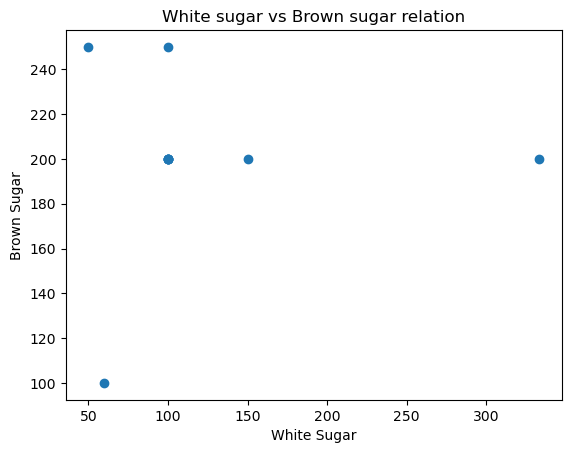

In [99]:
import matplotlib.pyplot as plt

plt.scatter(df_mix["white"], df_mix["brown"])
plt.xlabel("White Sugar")
plt.ylabel("Brown Sugar")
plt.title("White sugar vs Brown sugar relation")
plt.show()

In [100]:
#---Do a quick analysis of vanilla, salt, baking powder and extra toppings and do basic conditions for these; they are not important for the structure. so spend less time on them---

In [101]:
df_vanilla = df[df["ingredient_type"] == "vanilla"]

In [102]:
df_vanilla["grams_converted"].isna().sum()

np.int64(0)

In [103]:
df_vanilla_grouped = df_vanilla.groupby("Recipe_url")["grams_converted"].sum().reset_index()

df_vanilla_ratios = df_vanilla_grouped.merge(df_pivot[["Recipe_url", "flour"]], on="Recipe_url")

In [104]:
df_vanilla_ratios.sample(20)

,Recipe_url,grams_converted,flour
17,https://www.food.com/recipe/classic-blondies-5...,30.0,360.0
18,https://www.giftofhospitality.com/really-good-...,5.0,180.0
11,https://sugarspunrun.com/blondies-recipe/,10.0,270.0
29,https://www.yellowblissroad.com/classic-blondi...,7.5,120.0
1,https://bromabakery.com/the-best-chewy-blondies/,15.0,120.0
24,https://www.smalltownwoman.com/blondies-recipe/,10.0,240.0
27,https://www.thepioneerwoman.com/food-cooking/r...,15.0,240.0
21,https://www.rachelcooks.com/blondie-recipe/,10.0,120.0
14,https://www.biggerbolderbaking.com/best-ever-b...,15.0,284.0
6,https://handletheheat.com/blondie-recipe/,10.0,191.0


In [105]:
df_vanilla_ratios["vanilla_to_flour"] = df_vanilla_ratios["grams_converted"] / df_vanilla_ratios["flour"]

In [106]:
df_vanilla_ratios["vanilla_to_flour"].describe()

count    30.000000
mean      0.053343
std       0.026581
min       0.017857
25%       0.039714
50%       0.041667
75%       0.062500
max       0.125000
Name: vanilla_to_flour, dtype: float64

In [107]:
#---Convert vanilla extract values from g/mL to teaspoons and tablespoons for ease of use---

def format_vanilla(vanilla_ml):

    tsp = vanilla_ml / 5
    tsp_rounded = round(tsp)

    tbsp = tsp_rounded // 3
    remaining_tsp = tsp_rounded % 3

    if tbsp > 0 and remaining_tsp > 0:
        return f"{tbsp} tbsp + {remaining_tsp} tsp"
    elif tbsp > 0:
        return f"{tbsp} tbsp"
    else:
        return f"{remaining_tsp} tsp"

In [108]:
df_baking_powder = df[df["ingredient_type"] == "baking_powder"]

In [109]:
df_baking_powder_grouped = df_baking_powder.groupby("Recipe_url")[["grams_converted"]].sum().reset_index()

df_baking_powder_ratios = df_baking_powder_grouped.merge(df_pivot[["Recipe_url", "flour"]], on="Recipe_url", how="left")


In [110]:
df_baking_powder_ratios["bp_to_flour"] = df_baking_powder_ratios["grams_converted"] / df_baking_powder_ratios["flour"]

In [111]:
df_baking_powder_ratios["bp_to_flour"].describe()

count    25.000000
mean      0.022865
std       0.037844
min       0.004167
25%       0.009524
50%       0.016667
75%       0.019531
max       0.200000
Name: bp_to_flour, dtype: float64

In [112]:
df_baking_powder_ratios.sample(20)

,Recipe_url,grams_converted,flour,bp_to_flour
9,https://joythebaker.com/2023/02/my-best-classi...,4.0,190.0,0.021053
14,https://www.bbcgoodfood.com/recipes/easy-blondies,2.0,200.0,0.010000
10,https://moleinthewall.com/classic-blondie-recipe/,24.0,120.0,0.200000
19,https://www.rachelcooks.com/blondie-recipe/,2.0,120.0,0.016667
15,https://www.cookwithkushi.com/best-blondie-rec...,4.0,300.0,0.013333
2,https://cakesbymk.com/recipe/easy-blondies-rec...,2.0,210.0,0.009524
21,https://www.smalltownwoman.com/blondies-recipe/,4.0,240.0,0.016667
0,https://ashbaber.com/easy-fudgy-blondies/,1.0,240.0,0.004167
3,https://cheflindseyfarr.com/classic-chewy-blon...,5.0,270.0,0.018519
16,https://www.food.com/recipe/classic-blondies-5...,8.0,360.0,0.022222


In [113]:
df[df["ingredient_type"] == "baking_powder"]["Recipe_url"].nunique()

26

In [114]:
df_baking_powder_ratios.groupby("grams_converted")["flour"].max()

grams_converted
1.0     240.0
2.0     270.0
2.5     128.0
4.0     300.0
5.0     270.0
6.0     240.0
8.0     360.0
24.0    120.0
Name: flour, dtype: float64

In [115]:
def format_baking_powder(bp_g):
    tsp = bp_g / 4
    tsp_rounded = round(tsp * 4) / 4  # round to nearest 1/4 tsp

    formats = {
        0.25: "1/4 tsp",
        0.5: "1/2 tsp",
        0.75: "3/4 tsp",
        1.0: "1 tsp"
    }

    if tsp_rounded in formats:
        return formats[tsp_rounded]
    else:
        return f"{tsp_rounded:g} tsp"

In [ ]:
def blondie_ingredient_calculator_v3(flour=None, butter=None, sugar=None):

    butter_to_flour = df_pivot["butter_to_flour"].median()
    sugar_to_flour = df_pivot["sugar_to_flour"].median()
    vanilla_to_flour = df_vanilla_ratios["vanilla_to_flour"].median()
    baking_powder_to_flour = df_baking_powder_ratios["bp_to_flour"].median()

    inputs_provided = sum(x is not None and x !=0 for x in [flour, butter, sugar])

    if inputs_provided == 0:
        return "Please provide one ingredient."
    if inputs_provided > 1:
        return "Please provide ONLY one ingredient at a time."

    # --- Convert everything to flour ---
    if butter is not None and butter != 0:
        flour = butter / butter_to_flour
    elif sugar is not None and sugar != 0:
        flour = sugar / sugar_to_flour

    # --- Recompute consistently ---
    butter = flour * butter_to_flour
    sugar = flour * sugar_to_flour

    # --- Vanilla ---
    vanilla_ml = flour * vanilla_to_flour
    vanilla_text = format_vanilla(vanilla_ml)

    # --- Baking Powder ---
    baking_powder_g = flour * baking_powder_to_flour
    baking_powder_text = format_baking_powder(baking_powder_g)

    # --- Eggs ---
    eggs = estimate_eggs(flour, butter)

    result = {
        "flour_g": round(flour, 1),
        "baking_powder": baking_powder_text,
        "butter_g": round(butter, 1),
        "brown_sugar_g": round(sugar, 1),
        "eggs": eggs,
        "vanilla_extract": vanilla_text,
        'optional': "Add 2 tsp cornstarch for extra tenderness, an extra egg yolk for maximum fudginess, or both!"
    }

    ingredient_list = f"""Ingredients:
    - All-purpose Flour: {round(flour, 1)}g
    - Butter (Salted or Unsalted): {round(butter, 1)}g
    - Brown Sugar: {round(sugar, 1)}g
    - Egg(s): {eggs}
    - Vanilla Extract: {vanilla_text}
    - Baking Powder: {baking_powder_text}
    Optional: {result['optional']}
    """
    
    cooking_instructions = """
    Instructions:
    1. Preheat oven to 180°C (350°F). Line a baking pan with parchment paper.
    2. Melt the butter. After it has cooled down, mix with the sugar and vanilla extract until combined.
    3. Beat in the eggs one at a time until fully combined. If using an extra egg yolk, add it in with the eggs.
    4. In a separate container, sift all the dry ingredients together (flour, baking powder, and cornstarch if using).
    5. Fold the dry ingredients into the wet ingredients until just combined.
    6. Fold in chocolate chips, chopped baking chocolate, nuts, or any other add-ins if using. Get creative, folks!
    7. Pour into the pan and bake for 20-25 minutes or until the top is browned and a toothpick inserted one inch from the edge comes out with moist crumbs.
    8. Let the blondie cool at room temperature for 1-2 hours, then refrigerate for at least one hour before serving.
    9. Sprinkle flaky salt on top and enjoy!
    
    Notes:
    - If using unsalted butter, add 1/2 tsp of table salt to the dry ingredients in step 4.
    - Use chopped baking chocolate instead of chocolate chips if you want pools of melted chocolate in the final bake. Mix them both for the best of both worlds!
    - Replacing some brown sugar with white sugar dials back the caramel intensity and gives the top a slight crackle.  
    """

    return result

In [117]:
blondie_ingredient_calculator_v3(butter=150)

{'flour_g': 160.0,
 'baking_powder': '3/4 tsp',
 'butter_g': 150.0,
 'brown_sugar_g': 245.6,
 'eggs': 1,
 'vanilla_extract': '1 tsp',
 'optional': 'Add 2 tsp cornstarch for extra tenderness, an extra egg yolk for maximum fudginess, or both!'}

In [138]:
import gradio as gr

def blondie_recipe_generator(ingredient, amount):
    if ingredient == "Flour":
        result = blondie_ingredient_calculator_v3(flour=amount)
    elif ingredient == "Butter":
        result = blondie_ingredient_calculator_v3(butter=amount)
    elif ingredient == "Sugar":
        result = blondie_ingredient_calculator_v3(sugar=amount)
    

    ingredient_list = f"""
    Ingredients:
    - All-purpose Flour: {result['flour_g']}g
    - Butter (Salted or Unsalted): {result['butter_g']}g
    - Brown Sugar: {result['brown_sugar_g']}g
    - {'Eggs' if result['eggs'] > 1 else 'Egg'}: {result['eggs']}
    - Vanilla Extract: {result['vanilla_extract']}
    - Baking Powder: {result['baking_powder']}
    Optional: {result['optional']}
    """
    
    cooking_instructions = """
    Instructions:
    1. Preheat oven to 180°C (350°F). Line a baking pan with parchment paper.
    2. Melt the butter. After it has cooled down, mix with the sugar and vanilla extract until combined.
    3. Beat in the eggs one at a time until fully combined. If using an extra egg yolk, add it in with the eggs.
    4. In a separate container, sift all the dry ingredients together (flour, baking powder, and cornstarch if using).
    5. Fold the dry ingredients into the wet ingredients until just combined.
    6. Fold in chocolate chips, chopped baking chocolate, nuts, or any other add-ins if using. Get creative, folks!
    7. Pour into the pan and bake for 20-25 minutes or until the top is browned and a toothpick inserted one inch from the edge comes out with moist crumbs.
    8. Let the blondie cool at room temperature for 1-2 hours, then refrigerate for at least one hour before serving.
    9. Sprinkle flaky salt on top and enjoy!
    
    Notes:
    - If using unsalted butter, add 1/2 tsp of table salt to the dry ingredients in step 4.
    - Use chopped baking chocolate instead of chocolate chips if you want pools of melted chocolate in the final bake. Mix them both for the best of both worlds!
    - Blondies traditionally use all brown sugar, which is responsible for the caramel flavour and browning. If you only have white sugar, that works too — you'll get a delicious blondie with a crinkly top, just without the caramel depth. Replacing some of the brown sugar with white gives you both the caramel flavour and the crinkly top. 
    """
    return ingredient_list + cooking_instructions

interface = gr.Interface(
    fn=blondie_recipe_generator,
    inputs=[
        gr.Dropdown(label="Select Ingredient", choices=["Flour", "Butter", "Sugar"]),
        gr.Number(label="Enter Amount in grams", precision=1, value=None)
    ],
    outputs=gr.Textbox(label="Your Blondie Recipe"),
    title="Blondie Recipe Generator",
    description="Select an ingredient, enter the amount in grams, and get a complete blondie recipe scaled to your kitchen."
)

interface.launch(theme=gr.themes.Ocean())

* Running on local URL:  http://127.0.0.1:7879
* To create a public link, set `share=True` in `launch()`.
